In [26]:
import torch.nn as nn
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as T
from utils import *
from torch.utils.data import DataLoader
from models import *
import random
from collections import Counter
from collections import OrderedDict
import seaborn as sns
import copy

cos = nn.CosineSimilarity(dim=0, eps=1e-9) 
device = "cuda"

# study 1 model's training with the new loss function with dist limits

# adjustable parameters
alpha_d = 100 # IID
iters = 25
n_clients = 100 # dataset size for one client
mali_local_ep = 5
global attack 
attack = "untargeted" #"backdoor", "tlp", "ut"
model_name = "ConvNet" # "resnet8", "ConvNet"
num_classes = 10
dataset ="fmnist" # "cifar10", "fmnist"

In [27]:
def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}

# # Example usage
# model = nn.Sequential(
#     nn.Linear(10, 5),
#     nn.BatchNorm1d(5),  # This has buffers (running_mean, running_var) in state_dict but not in parameters
#     nn.Linear(5, 2)
# )

# filtered_state_dict = filter_trainable_state_dict(model)
# print(filtered_state_dict.keys())  # Only includes trainable parameters


In [28]:
def cos_dist(w1, w2):
    """Compute cosine similarity between two flattened weight tensors"""
    w1_flat, w2_flat = torch.cat([p.view(-1) for p in w1]), torch.cat([p.view(-1) for p in w2])
    return 1 - torch.dot(w1_flat, w2_flat) / (torch.norm(w1_flat) * torch.norm(w2_flat))

def get_delta_cos(model1, model2, model0_sd):
    flat_model0 = flat_dict(model0_sd)
    flat_model1 = flat_dict(model1.state_dict())
    flat_model2 = flat_dict(model2.state_dict())
    
    delta = torch.abs(flat_model1 - flat_model2)
    org_cos = cos((flat_model1 - flat_model0), (flat_model2 - flat_model0))
    return delta, 1-org_cos.item()

def model_eval(model, test_loader, attack):
    acc = eval_op_ensemble([model], test_loader)
    if attack == "tlp":
        asr = eval_op_ensemble_tr_lf_attack([model], test_loader)
    elif attack == "backdoor":
        asr = eval_op_ensemble_attack([model], test_loader)
    elif attack == "untargeted":
        asr = None
    return list(acc.values())[0], list(asr.values())[0]

def restore_dict_w_flat(param_flat, model_dict):
    restored_w = {}
    start = 0
    for name, param in model_dict.items():
            num_elements = param.numel()
            restored_w[name] = param_flat[start:start + num_elements].view(param.shape)                          
            start += num_elements
    return restored_w

def filter_trainable_state_dict(model):
    """
    Filters model.state_dict() to retain only parameters that are in model.parameters().

    Args:
        model (torch.nn.Module): The model whose state_dict needs filtering.

    Returns:
        dict: Filtered state dictionary containing only trainable parameters.
    """
    param_names = {name for name, _ in model.named_parameters()}
    return {k: v for k, v in model.state_dict().items() if k in param_names}


def train_rev_w_cos(model, loader, optimizer, scheduler, epochs, model0, model1, beta, budget):    
    model.train()
    # model.parameters need to use 
    flat_model0 = flat_dict(filter_trainable_state_dict(model0))
    flat_model1 = flat_dict(filter_trainable_state_dict(model1))
    
    losses = []
    running_loss, samples = 0.0, 0
    print(f"data length {len(loader) * loader.batch_size}: batches {len(loader)}, batch_size {loader.batch_size}")
    
    last_mail_w = flat_model0.clone().detach()
    for ep in range(epochs):
        for it, (x, y) in enumerate(loader):
            if it % 2 == 0:
                losses.append(round(eval_epoch(model, loader), 2))
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            # 1 negative CE loss
            loss_ce = nn.CrossEntropyLoss(reduction="mean")(model(x), y)
            loss_oppo_ce = - loss_ce

            running_loss += loss_oppo_ce.item() * y.shape[0]
            samples += y.shape[0]
            
            # add cos loss 
            w = torch.cat([p.view(-1) for p in model.parameters()]).to(device)
            target = torch.ones(len(w)).to(device)
            loss_cos = nn.CosineEmbeddingLoss()(flat_model0.unsqueeze(0), w.unsqueeze(0), target)
            
            # combindation loss
            loss_obj = (1-beta) * loss_oppo_ce + beta * loss_cos
            # only negative loss
            # loss_obj = loss_oppo_ce 
            
            loss_obj.backward()
            optimizer.step()
            scheduler.step()
            if it % 5 == 0:
                print(f"ep{ep}, loss_ce: {loss_oppo_ce:.2f}, loss_cos: {loss_cos:.6f}, loss_obj: {loss_obj:.2f}, lr: {optimizer.param_groups[0]['lr']}")
        
        # break
        crafted_cos_d = cos_dist_w(flat_model0, w)
        print(f"cos_d: {crafted_cos_d}, budget: {budget}")

        if crafted_cos_d > budget:
            print(f"budget exceeded, finish training early, ep = {ep}")
            break
        
        last_mail_w = w
        
    # craft_g = combine_tensors(B=grad_ben, M=grad_mail, budget=budget)
    craft_w = craft_tensor(B=flat_model0, M1=last_mail_w, M2=w, k=budget)
    
    # restored_crafted = restore_dict_grad_flat(craft_w, model0.state_dict(), model.state_dict())
    restored_crafted = restore_dict_w_flat(craft_w, model.state_dict())
    model.load_state_dict(restored_crafted)
    crafted_cos_d = cos_dist_w(flat_model0, craft_w)
        
    print(f"crafted cos_d: {crafted_cos_d}")        

    return {"loss": running_loss / samples}
    

In [29]:
# Define transformation (convert images to tensors and normalize)
transform_img = T.Compose([
    T.ToTensor(),  # Convert image to tensor
    T.Normalize((0.5,), (0.5,))  # Normalize the image with mean and std
])

if dataset == "fmnist":
    # Load the training dataset
    train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_img)
    # Load the test dataset
    test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_img)
elif dataset == "cifar10":
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_img)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_img)

# Create DataLoader for batch processing
client_loaders, test_loader, client_data_subsets =\
    data.get_loaders(train_data, test_data, n_clients,
                    alpha=alpha_d, batch_size=32, n_data=None, num_workers=4, seed=4)
    
model_fn = partial(models.get_model(model_name)[
                        0], num_classes=num_classes, dataset=dataset)

client_loader = client_loaders[0]

# created models 
model0 = model_fn().to(device) # orginal model
model1 = model_fn().to(device) # train with clean data
model2 = model_fn().to(device) # train with new loss function
model3 = model_fn().to(device)

model0_sd = {k: v.clone().detach() for k, v in model1.state_dict().items()}

optimizer0 = optim.SGD(model0.parameters(), lr=0.001)
optimizer1 = optim.SGD(model1.parameters(), lr=0.001)

optimizer3 = optim.SGD(model3.parameters(), lr=0.001)



Data split:
 - Client 0: [62 62 58 65 57 61 58 53 56 63]                         -> sum=595
 - Client 1: [61 64 63 55 59 58 60 65 57 58]                         -> sum=600
 - Client 2: [54 57 59 60 64 66 62 63 60 54]                         -> sum=599
 - Client 3: [62 56 63 56 62 63 59 58 61 61]                         -> sum=601
 - Client 4: [57 67 62 56 57 65 65 57 54 58]                         -> sum=598
 - Client 5: [54 51 65 59 66 67 53 57 62 68]                         -> sum=602
 - Client 6: [61 65 60 67 53 60 61 50 58 66]                         -> sum=601
 - Client 7: [53 58 49 70 75 63 51 61 54 64]                         -> sum=598
 - Client 8: [64 58 60 52 59 66 65 64 55 59]                         -> sum=602
 - Client 9: [58 63 46 68 61 56 57 66 69 55]                         -> sum=599
.  .  .  .  .  .  .  .  .  .  
.  .  .  .  .  .  .  .  .  .  
.  .  .  .  .  .  .  .  .  .  
 - Client 91: [54 61 56 53 60 63 63 62 70 58]                         -> sum=600
 - Client 92: 

In [30]:
def mali_model_craft_w_budget(model0, model1, model2, client_loader, budget):
    # craft model2 train with new loss function
    optimizer2 = optim.SGD(model2.parameters(), lr=0.05) # 0.001
    scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=1)

    model2.load_state_dict(model1.state_dict())
    model2_result_before = eval_op_ensemble([model2], test_loader)
    
    train_rev_w_cos(model2, client_loader, optimizer2, scheduler2, epochs=4, 
                                    model0 = model0, 
                                    model1 = model1, 
                                    beta = 0.5, 
                                    budget = budget)
    
    cos_d = cos_dist(flat_dict(filter_trainable_state_dict(model1)),
                         flat_dict(filter_trainable_state_dict(model2)))
    
    model2_result = eval_op_ensemble([model2], test_loader)
    
    return cos_d, model2_result, model2_result_before 

In [31]:
from collections import OrderedDict

def average_state_dicts(state_dicts):
    """
    Averages a list of PyTorch model state dictionaries.
    
    Args:
        state_dicts (list): A list of state_dicts from different models.
    
    Returns:
        OrderedDict: A state_dict with averaged parameters.
    """
    if not state_dicts:
        raise ValueError("The state_dicts list is empty.")
    
    # Initialize an empty OrderedDict to store the averaged values
    avg_state_dict = OrderedDict()
    
    # Get the keys from the first model (assumes all have the same keys)
    keys = state_dicts[0].keys()
    
    for key in keys:
        # Stack the tensors across models and compute the mean
        avg_state_dict[key] = sum(d[key] for d in state_dicts) / len(state_dicts)
    
    return avg_state_dict

In [32]:
# train without FedAvg
server_model = model0
lembda_ = 1
results = []
for it in range(iters):
    print("iteration", it)
    train_op(model1, client_loader, optimizer1, epochs=1, print_train_loss=True)
    model1_sd = {key: value.clone() for key, value in model1.state_dict().items()}
    model1_result = eval_op_ensemble([model1], test_loader)
    
    # train model2 with new loss function
    cos_d, model2_result, model2_result_before = mali_model_craft_w_budget(model0=server_model,
                                                                           model1=model1, 
                                                                           model2=model2, 
                                                                           client_loader=client_loader, 
                                                                           budget=0.01)
    flat_grad_benign = flat_dict(filter_trainable_state_dict(model1)) 
    flat_grad_mali = flat_dict(filter_trainable_state_dict(model2)) 
    
    flat_grad_mali = flat_grad_mali / torch.norm(flat_grad_mali, p=2) * torch.norm(flat_grad_benign, p=2) 
    
    cos_d = 1- cos(flat_grad_benign, flat_grad_mali)
    
    r_w = restore_dict_grad_flat(flat_grad_mali * lembda_, server_model.state_dict(), server_model.state_dict())
    model2.load_state_dict(r_w)
    model2_result_after = eval_op_ensemble([model2], test_loader)
    
    
    # averaging between benign and crafted model
    model3.load_state_dict(average_state_dicts([ model1.state_dict(),  model2.state_dict()]))
    model3_result = eval_op_ensemble([model3], test_loader)
    server_model = copy.deepcopy(model1)

    print(it, cos_d, model1_result, model2_result, model2_result_after, model3_result)
    
    results.append([it, cos_d, model1_result, model2_result, model2_result_after, model3_result])

iteration 0
[2.31, 2.26, 2.2, 2.16, 2.13, 2.08, 2.04, 2.01, 1.97, 1.94]
data length 608: batches 19, batch_size 32
ep0, loss_ce: -1.93, loss_cos: 0.258611, loss_obj: -0.84, lr: 0.05
ep0, loss_ce: -49.85, loss_cos: 0.260830, loss_obj: -24.79, lr: 0.05
ep0, loss_ce: -153.41, loss_cos: 0.275104, loss_obj: -76.57, lr: 0.05
ep0, loss_ce: -375.47, loss_cos: 0.308606, loss_obj: -187.58, lr: 0.05
cos_d: 0.3423095941543579, budget: 0.01
budget exceeded, finish training early, ep = 0
alpha_tensor tensor(0.8566)
crafted cos_d: 0.009999990463256836
0 tensor(0.1963, device='cuda:0') {'test_accuracy': 0.49} {'test_accuracy': 0.1} {'test_accuracy': 0.1} {'test_accuracy': 0.1}
iteration 1
[1.92, 1.89, 1.87, 1.84, 1.82, 1.79, 1.77, 1.74, 1.72, 1.7]
data length 608: batches 19, batch_size 32
ep0, loss_ce: -1.70, loss_cos: 0.000004, loss_obj: -0.85, lr: 0.05
ep0, loss_ce: -39.07, loss_cos: 0.002772, loss_obj: -19.53, lr: 0.05
ep0, loss_ce: -150.97, loss_cos: 0.026746, loss_obj: -75.47, lr: 0.05
ep0, loss

In [33]:
def normalize_to_C(x, C):
    norm_x = torch.norm(x, p=2, dim=-1, keepdim=True)  # Compute L2 norm
    return (x / norm_x) * C

In [34]:
# train with FedAvg
server_model = deepcopy(model0)
lembda_ = 1
results = []
for it in range(iters):
    print("iteration", it)
    model1.load_state_dict(server_model.state_dict())
    train_op(model1, client_loader, optimizer1, epochs=1, print_train_loss=True)
    model1_result = eval_op_ensemble([model1], test_loader)
    
    # train model2 with new loss function
    cos_d, model2_result, model2_result_before = mali_model_craft_w_budget(model0=server_model,
                                                                           model1=model1, 
                                                                           model2=model2, 
                                                                           client_loader=client_loader, 
                                                                           budget=0.01)
    flat_grad_benign = flat_dict(filter_trainable_state_dict(model1)) - flat_dict(filter_trainable_state_dict(server_model))
    flat_grad_mali = flat_dict(filter_trainable_state_dict(model2)) - flat_dict(filter_trainable_state_dict(server_model))
    
    flat_grad_mali = normalize_to_C(flat_grad_mali, torch.norm(flat_grad_benign, p=2) )
    
    cos_d = 1 - cos(flat_dict(filter_trainable_state_dict(model1)), flat_dict(filter_trainable_state_dict(model2)))
    
    r_w = restore_dict_grad_flat(flat_grad_mali * lembda_, server_model.state_dict(), server_model.state_dict())
    model2.load_state_dict(r_w)
    model2_result_after = eval_op_ensemble([model2], test_loader)
    
    
    # averaging between benign and crafted model
    model3.load_state_dict(average_state_dicts([ model1.state_dict(),  model2.state_dict()]))
    model3_result = eval_op_ensemble([model3], test_loader)
    server_model = copy.deepcopy(model3)

    print(it, cos_d, model1_result, model2_result, model2_result_after, model3_result)
    
    results.append([it, cos_d, model1_result, model2_result, model2_result_after, model3_result])

iteration 0
[2.39, 2.34, 2.29, 2.24, 2.2, 2.15, 2.11, 2.06, 2.03, 1.99]
data length 608: batches 19, batch_size 32
ep0, loss_ce: -2.02, loss_cos: 0.000008, loss_obj: -1.01, lr: 0.05
ep0, loss_ce: -30.87, loss_cos: 0.002068, loss_obj: -15.43, lr: 0.05
ep0, loss_ce: -131.85, loss_cos: 0.024742, loss_obj: -65.91, lr: 0.05
ep0, loss_ce: -331.59, loss_cos: 0.078315, loss_obj: -165.76, lr: 0.05
cos_d: 0.12459468841552734, budget: 0.01
budget exceeded, finish training early, ep = 0
alpha_tensor tensor(0.7596)
crafted cos_d: 0.009999990463256836
0 tensor(0.0101, device='cuda:0') {'test_accuracy': 0.4603} {'test_accuracy': 0.1} {'test_accuracy': 0.1} {'test_accuracy': 0.1009}
iteration 1
[2.23, 2.16, 2.1, 2.05, 2.01, 1.97, 1.94, 1.91, 1.88, 1.86]
data length 608: batches 19, batch_size 32
ep0, loss_ce: -1.86, loss_cos: 0.000007, loss_obj: -0.93, lr: 0.05
ep0, loss_ce: -48.07, loss_cos: 0.003283, loss_obj: -24.04, lr: 0.05
ep0, loss_ce: -140.80, loss_cos: 0.030074, loss_obj: -70.39, lr: 0.05
ep0

In [35]:
results

[[0,
  tensor(0.0101, device='cuda:0'),
  {'test_accuracy': 0.4603},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1009}],
 [1,
  tensor(0.0100, device='cuda:0'),
  {'test_accuracy': 0.5183},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1001},
  {'test_accuracy': 0.2194}],
 [2,
  tensor(0.0101, device='cuda:0'),
  {'test_accuracy': 0.5724},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.279}],
 [3,
  tensor(0.0100, device='cuda:0'),
  {'test_accuracy': 0.5981},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1023},
  {'test_accuracy': 0.3161}],
 [4,
  tensor(0.0100, device='cuda:0'),
  {'test_accuracy': 0.6473},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.232},
  {'test_accuracy': 0.4588}],
 [5,
  tensor(0.0101, device='cuda:0'),
  {'test_accuracy': 0.6455},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.2122},
  {'test_accuracy': 0.4355}],
 [6,
  tensor(0.0101, device='cuda:0'),
  {'test_accuracy': 0.6662},
  {'test_accura

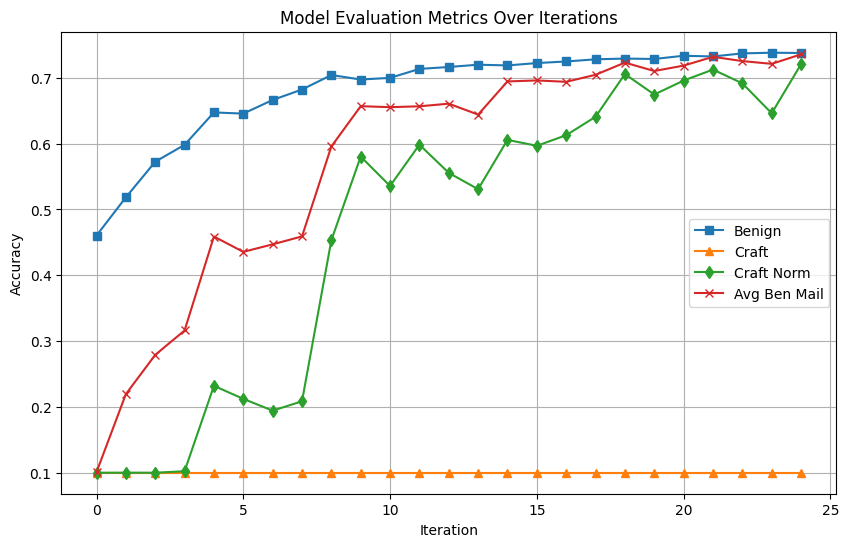

In [36]:
import matplotlib.pyplot as plt

# Data
# results = [
#     [0, torch.tensor(0.0256, device='cuda:0'), {'test_accuracy': 0.4534}, {'test_accuracy': 0.1}, {'test_accuracy': 0.1}, {'test_accuracy': 0.1}],
#     [1, torch.tensor(0.0358, device='cuda:0'), {'test_accuracy': 0.5347}, {'test_accuracy': 0.1}, {'test_accuracy': 0.1001}, {'test_accuracy': 0.1067}],
#     [2, torch.tensor(0.0331, device='cuda:0'), {'test_accuracy': 0.6094}, {'test_accuracy': 0.1}, {'test_accuracy': 0.1546}, {'test_accuracy': 0.2247}],
#     [3, torch.tensor(0.0312, device='cuda:0'), {'test_accuracy': 0.6491}, {'test_accuracy': 0.1}, {'test_accuracy': 0.1141}, {'test_accuracy': 0.3377}]
# ]

# Extract values
iterations = [item[0] for item in results]
cos_d = [item[1].item() for item in results]  # Convert tensor to float
benign = [item[2]['test_accuracy'] for item in results]
craft = [item[3]['test_accuracy'] for item in results]
craft_norm = [item[4]['test_accuracy'] for item in results]
avg_ben_mail = [item[5]['test_accuracy'] for item in results]

# Plot
plt.figure(figsize=(10, 6))
# plt.plot(iterations, cos_d, marker='o', label='Cos_d')
plt.plot(iterations, benign, marker='s', label='Benign')
plt.plot(iterations, craft, marker='^', label='Craft')
plt.plot(iterations, craft_norm, marker='d', label='Craft Norm')
plt.plot(iterations, avg_ben_mail, marker='x', label='Avg Ben Mail')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Model Evaluation Metrics Over Iterations')
plt.legend()
plt.grid()
plt.show()


## if norm are the same

In [37]:
flat_grad_benign = flat_dict(filter_trainable_state_dict(model1)) - flat_dict(filter_trainable_state_dict(model0))
flat_grad_mali = flat_dict(filter_trainable_state_dict(model2)) - flat_dict(filter_trainable_state_dict(model0))

torch.norm(flat_grad_mali, p=2)

tensor(0.5865, device='cuda:0')

In [38]:
flat_grad_mali = flat_grad_mali / torch.norm(flat_grad_mali, p=2) * torch.norm(flat_grad_benign, p=2) 
torch.norm(flat_grad_benign, p=2), torch.norm(flat_grad_mali, p=2)

(tensor(0.5977, device='cuda:0'), tensor(0.5977, device='cuda:0'))

In [39]:
r_w = restore_dict_grad_flat(flat_grad_mali, model0.state_dict(), model0.state_dict())

In [40]:
model2.load_state_dict(r_w)

<All keys matched successfully>

In [41]:
eval_op_ensemble([model2], test_loader)

{'test_accuracy': 0.7212}

## series experiments

In [42]:
# budgets = np.linspace(1e-7, 1e-3, 10)
budgets = np.logspace(np.log10(5e-7), np.log10(0.001), 10)
budgets

array([5.00000000e-07, 1.16345908e-06, 2.70727408e-06, 6.29960525e-06,
       1.46586659e-05, 3.41095160e-05, 7.93700526e-05, 1.84687617e-04,
       4.29752973e-04, 1.00000000e-03])

In [43]:
results = {}
for b in budgets:
    cos_d, model2_result, model2_result_before = mali_model_craft_w_budget(model2, client_loader, b)
    print("cos_d, model2_result", cos_d, model2_result)
    results[float(b)] = (cos_d.item(), list(model2_result.values())[0])

TypeError: mali_model_craft_w_budget() missing 2 required positional arguments: 'client_loader' and 'budget'

In [ ]:
results

[[0,
  tensor(0.0328, device='cuda:0'),
  {'test_accuracy': 0.5392},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1},
  {'test_accuracy': 0.1}],
 [1,
  tensor(0.0500, device='cuda:0'),
  {'test_accuracy': 0.6356},
  {'test_accuracy': 0.4823},
  {'test_accuracy': 0.1127},
  {'test_accuracy': 0.4262}],
 [2,
  tensor(0.0500, device='cuda:0'),
  {'test_accuracy': 0.6747},
  {'test_accuracy': 0.5964},
  {'test_accuracy': 0.1137},
  {'test_accuracy': 0.5253}],
 [3,
  tensor(0.0500, device='cuda:0'),
  {'test_accuracy': 0.6961},
  {'test_accuracy': 0.6743},
  {'test_accuracy': 0.1274},
  {'test_accuracy': 0.5424}],
 [4,
  tensor(0.0392, device='cuda:0'),
  {'test_accuracy': 0.7046},
  {'test_accuracy': 0.6981},
  {'test_accuracy': 0.114},
  {'test_accuracy': 0.5686}],
 [5,
  tensor(0.0500, device='cuda:0'),
  {'test_accuracy': 0.6949},
  {'test_accuracy': 0.6827},
  {'test_accuracy': 0.1172},
  {'test_accuracy': 0.5755}],
 [6,
  tensor(0.0432, device='cuda:0'),
  {'test_accuracy': 0.7134},

In [ ]:

cos_d_model1_2 = cos_dist(flat_dict(model1.state_dict()) - flat_dict(model0.state_dict()), 
                          flat_dict(model2.state_dict()) - flat_dict(model0.state_dict()))
print("model1_2 cos dist", cos_d_model1_2)



model1_2 cos dist tensor(0.0001, device='cuda:0')


In [ ]:
# visualization of the layers

import torch
import numpy as np
import matplotlib.pyplot as plt

def compare_model_weights(model1, model2):
    """
    Compare the weights of two PyTorch models layer by layer using bar charts.
    
    Args:
        model1 (torch.nn.Module): The first model to compare.
        model2 (torch.nn.Module): The second model to compare.
    
    Returns:
        None (displays a bar chart of L2 distance and cosine dissimilarity).
    """
    layer_names = []
    l2_distances = []
    cos_dissimilarities = []
    
    for (name1, param1), (name2, param2) in zip(model1.named_parameters(), model2.named_parameters()):
        if name1 != name2:
            raise ValueError(f"Layer mismatch: {name1} vs {name2}")
        
        layer_names.append(name1)
        param1_flat = param1.view(-1)
        param2_flat = param2.view(-1)
        
        l2_distance = torch.norm(param1_flat - param2_flat, p=2).item()
        l2_distances.append(l2_distance)
        
        cos_sim = torch.nn.functional.cosine_similarity(param1_flat, param2_flat, dim=0).item()
        cos_dissimilarities.append(1 - cos_sim)
    
    
    flat_grad_model1 = flat_dict(filter_trainable_state_dict(model1))
    flat_grad_model2 = flat_dict(filter_trainable_state_dict(model2))
    layer_names.append("all")
    
    l2_distance = torch.norm(flat_grad_model1 - flat_grad_model2, p=2).item()
    l2_distances.append(l2_distance)
        
    cos_sim = torch.nn.functional.cosine_similarity(flat_grad_model1, flat_grad_model2, dim=0).item()
    cos_dissimilarities.append(1 - cos_sim)
    
    # Plot results as bar charts
    x = np.arange(len(layer_names))  # Layer indices
    width = 0.35  # Width of the bars

    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Bar chart for L2 Distance
    ax1.bar(x - width/2, l2_distances, width, label="L2 Distance", color='tab:blue')
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("L2 Distance", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Bar chart for Cosine Dissimilarity
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, cos_dissimilarities, width, label="Cos Disimilarity", color='tab:red')
    ax2.set_ylabel("Cos Disimilarity", color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Add layer names to x-axis
    plt.xticks(x, layer_names, rotation=45, ha='right')
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)
    
    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    # Add title and layout adjustments
    plt.title("Layer-wise L2 Distance and Cosine Dissimilarity (Bar Chart)")
    # fig.tight_layout()
    plt.show()

In [44]:
compare_model_weights(model1, model2)

NameError: name 'compare_model_weights' is not defined

The L2 and Cosine distince is small in this attack

In [ ]:
import torch.nn as nn

# Example model
model = nn.Sequential(
    nn.Linear(10, 5),
    nn.BatchNorm1d(5),  # This has buffers (running_mean, running_var) in state_dict but not in parameters
    nn.Linear(5, 2)
)

# Get parameter names (those in model.parameters())
param_names = {name for name, param in model.named_parameters()}

# Filter state_dict keys that are in param_names
filtered_state_dict = {k: v for k, v in model.state_dict().items() if k in param_names}

# Display results
print(filtered_state_dict.keys())  # Only includes layers that are in model.parameters()


dict_keys(['0.weight', '0.bias', '1.weight', '1.bias', '2.weight', '2.bias'])


In [ ]:
import torch
import torch.nn.functional as F

# Define a reference tensor X
X = torch.tensor([1.0, 2.0, 3.0])

# Construct two different tensors A and B that are not scalar multiples but have the same cosine similarity to X
A = torch.tensor([2.0, 0.0, 1.0])  
B = torch.tensor([1.0, 3.0, 0.0])  

# Compute cosine similarities
cos_sim_A = F.cosine_similarity(A.unsqueeze(0), X.unsqueeze(0), dim=1)
cos_sim_B = F.cosine_similarity(B.unsqueeze(0), X.unsqueeze(0), dim=1)

print(f"Cosine similarity of A and X: {cos_sim_A.item()}")
print(f"Cosine similarity of B and X: {cos_sim_B.item()}")


Cosine similarity of A and X: 0.5976142883300781
Cosine similarity of B and X: 0.591607928276062


In [ ]:
import torch
import torch.nn.functional as F

def cosine_distance(x, y):
    # Compute cosine distance between two tensors
    return 1 - F.cosine_similarity(x, y, dim=-1)

def craft_tensor(B, M1, M2, k):
    # Compute cosine distances
    d_cos_B_M1 = cosine_distance(B, M1)
    d_cos_B_M2 = cosine_distance(B, M2)
    
    # Check conditions
    if d_cos_B_M2 > k and d_cos_B_M1 < k:
        # Find the weight alpha such that cos(B, C) = k
        # C = alpha * M1 + (1 - alpha) * M2
        # We need to solve for alpha such that cosine_distance(B, C) = k
        
        # Define a function to compute the cosine distance between B and C
        def objective(alpha):
            C = alpha * M1 + (1 - alpha) * M2
            return cosine_distance(B, C) - k
        
        # Use a numerical solver to find alpha
        from scipy.optimize import fsolve
        alpha_initial_guess = 0.5
        alpha = fsolve(objective, alpha_initial_guess)[0]
        
        # Craft the new tensor C
        C = alpha * M1 + (1 - alpha) * M2
        return C
    else:
        # If conditions are not met, return None or handle accordingly
        return None

# Example usage
B = torch.tensor([1.0, 0.0, 0.0])
M1 = torch.tensor([0.8, 0.2, 0.0])
M2 = torch.tensor([0.0, 0.0, 1.0])
k = 0.5

C = craft_tensor(B, M1, M2, k)
print(C)

TypeError: unsupported operand type(s) for *: 'numpy.ndarray' and 'Tensor'

In [ ]:
import torch
a = torch.tensor([1.0, 2.0, 3.0])

In [ ]:
a * 3

tensor([3., 6., 9.])

In [ ]:
import torch
import torch.nn.functional as F

class OppositeCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class

        correct_mask = (preds != targets).float()  # Mask where predictions are correct
        loss = - correct_mask * torch.log(probs[torch.arange(len(targets)), targets] + 1e-10)  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = OppositeCrossEntropyLoss()
logits = torch.tensor([[2.0, 1.0], [0.5, 1.5]])  # Model output (logits)
targets = torch.tensor([1, 0])  # True labels
loss = criterion(logits, targets)
print(loss)


tensor(1.3133)


In [ ]:
class ReverseCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class
        
        correct_mask = (preds == targets).float()  # Mask where predictions are correct
        loss = correct_mask * (-torch.log(1 - probs[torch.arange(len(targets)), targets] + 1e-10))  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = ReverseCrossEntropyLoss()
loss = criterion(logits, targets)
print(loss)

tensor(0.)


In [ ]:
import torch
import torch.nn.functional as F

class ReverseCrossEntropyLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=-1)  # Convert logits to probabilities
        preds = torch.argmax(probs, dim=-1)  # Get predicted class
        
        correct_mask = (preds == targets).float()  # Mask where predictions are correct
        loss = correct_mask * (-torch.log(1 - probs[torch.arange(len(targets)), targets] + 1e-10))  # Penalize correct predictions

        return loss.mean()  # Return mean loss

# Example usage
criterion = ReverseCrossEntropyLoss()
logits = torch.tensor([[0.0, 1.0], [0.5, 1.5]])  # Model output (logits)
targets = torch.tensor([0, 1])  # True labels
loss = criterion(logits, targets)
print(loss)


tensor(0.6566)


In [ ]:
a = {"a":1, "b":2, "c":3}

In [ ]:
a.values()

dict_values([1, 2, 3])

In [ ]:
for p in a.values():
    print(p)

1
2
3


In [ ]:
import torch.nn as nn
loss = nn.BCEWithLogitsLoss()
input = torch.randn(3, requires_grad=True)
target = torch.empty(3).random_(2)
output = loss(input, target)
output.backward()

In [ ]:
m = nn.Softmax(dim=0)
input = torch.randn(10)
output = m(input)
output

tensor([0.0303, 0.0065, 0.0311, 0.1110, 0.0261, 0.5034, 0.0473, 0.0147, 0.0566,
        0.1729])